In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
RAW_DIR = Path("../data/raw")

df = pd.read_csv(RAW_DIR / "dataset-tickets-multi-lang-4-20k.csv")
df = df[df["language"] == "en"].copy()

print("English tickets:", len(df))
df.head(2)

English tickets: 11923


,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN


In [2]:
print(df[["subject", "body", "queue", "priority", "type"]].isna().sum())
print("\nEmpty/whitespace bodies:", (df["body"].fillna("").str.strip() == "").sum())
print("Empty/whitespace subjects:", (df["subject"].fillna("").str.strip() == "").sum())

subject     1032
body           1
queue          0
priority       0
type           0
dtype: int64

Empty/whitespace bodies: 1
Empty/whitespace subjects: 1032


In [3]:
df["text"] = df["subject"].fillna("") + " " + df["body"].fillna("")

print("Exact duplicate bodies:", df["body"].duplicated().sum())
print("Exact duplicate full text:", df["text"].duplicated().sum())
print("Duplicate first 150 chars:", df["text"].str[:150].duplicated().sum())

Exact duplicate bodies: 0
Exact duplicate full text: 0
Duplicate first 150 chars: 13


count    11923.000000
mean        62.722972
std         36.436288
min          1.000000
25%         34.000000
50%         58.000000
75%         87.000000
max        276.000000
Name: n_words, dtype: float64


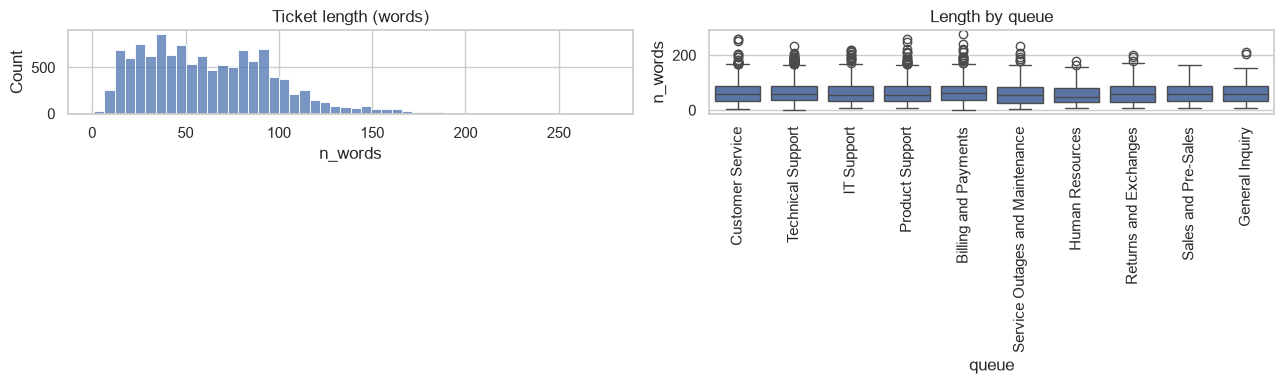

In [4]:
df["n_words"] = df["text"].str.split().str.len()
print(df["n_words"].describe())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["n_words"], bins=50, ax=ax[0])
ax[0].set_title("Ticket length (words)")
sns.boxplot(data=df, x="queue", y="n_words", ax=ax[1])
ax[1].tick_params(axis="x", rotation=90)
ax[1].set_title("Length by queue")
plt.tight_layout()
plt.show()

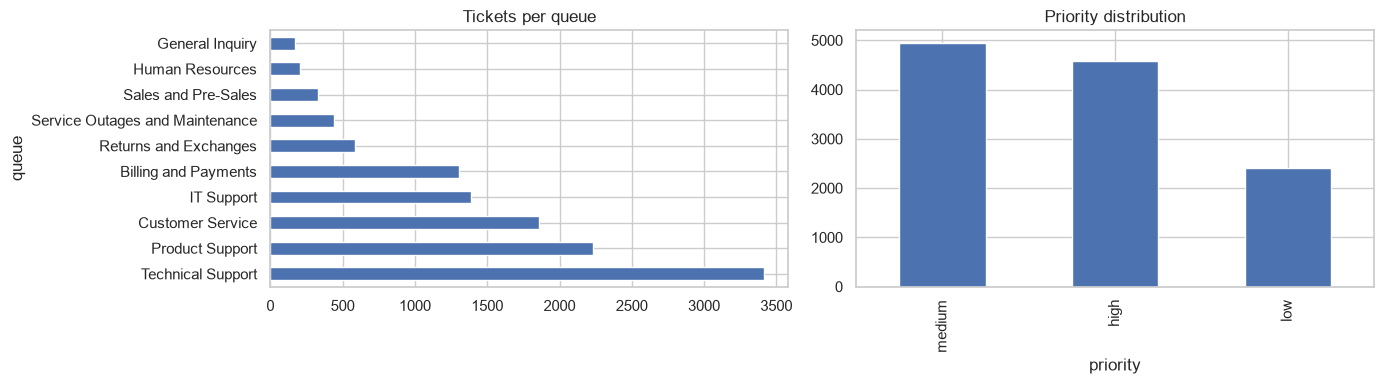

queue
Technical Support                  3412
Product Support                    2232
Customer Service                   1859
IT Support                         1391
Billing and Payments               1302
Returns and Exchanges               582
Service Outages and Maintenance     442
Sales and Pre-Sales                 330
Human Resources                     205
General Inquiry                     168
Name: count, dtype: int64

Imbalance ratio: 20.3


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df["queue"].value_counts().plot(kind="barh", ax=ax[0], title="Tickets per queue")
df["priority"].value_counts().plot(kind="bar", ax=ax[1], title="Priority distribution")
plt.tight_layout()
plt.show()

print(df["queue"].value_counts())
print("\nImbalance ratio:", round(df["queue"].value_counts().max() / df["queue"].value_counts().min(), 1))

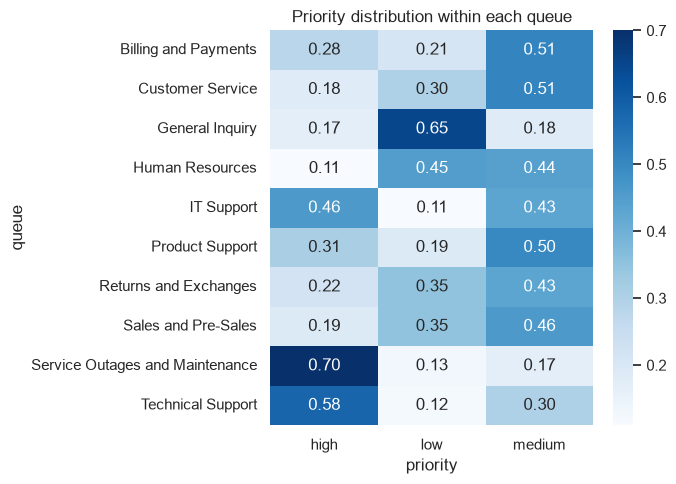

In [6]:
ct = pd.crosstab(df["queue"], df["priority"], normalize="index").round(2)
plt.figure(figsize=(7, 5))
sns.heatmap(ct, annot=True, cmap="Blues", fmt=".2f")
plt.title("Priority distribution within each queue")
plt.tight_layout()
plt.show()

In [7]:
sample = df.sample(20, random_state=42)
for _, r in sample.iterrows():
    print("\n" + "="*70)
    print(f"[{r['queue']} | {r['priority']} | {r['type']}]")
    print("SUBJECT:", r["subject"])
    print("BODY:", str(r["body"])[:400])


[Technical Support | low | Request]
SUBJECT: Request for Information on Smart-Thermometer Reporting Capabilities
BODY: I am reaching out to inquire about the reporting features available in Smart-Thermometer, particularly regarding data analytics integration. Could you please provide me with details on the types of reports that can be generated and the data that can be exported? Additionally, I would appreciate any guidance on how to integrate this data into our analytics platform. Thank you for your time and assi

[Billing and Payments | medium | Problem]
SUBJECT: Subject: Assistance Needed with Incorrect Invoice Totals
BODY: I am encountering problems with incorrect invoice totals due to a billing system glitch. Despite restarting, relogging, and resynchronizing data, the issue still exists. I would greatly appreciate your timely assistance in addressing this concern.

[Billing and Payments | medium | Incident]
SUBJECT: Security Incident Notification
BODY: Dear Customer Support, I h